# General preprocessing

## Normalization and standardization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

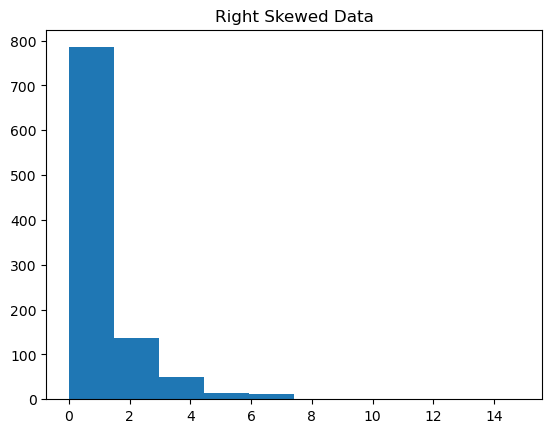

In [2]:
right_skew = np.random.normal(0, 1, size = 1000)**2

plt.hist(right_skew)
plt.title("Right Skewed Data")
plt.show()

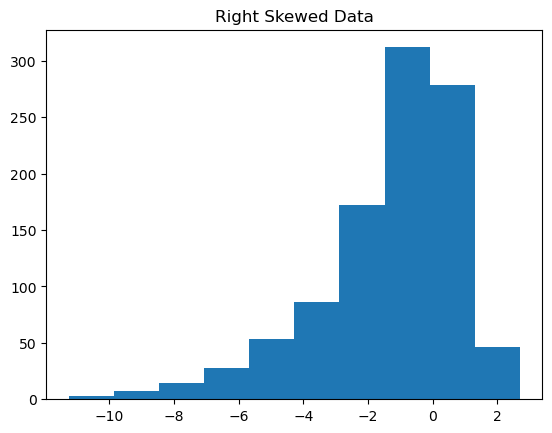

In [3]:
## Log transformation
right_skew_log = np.log(right_skew)

plt.hist(right_skew_log)
plt.title("Right Skewed Data")
plt.show()

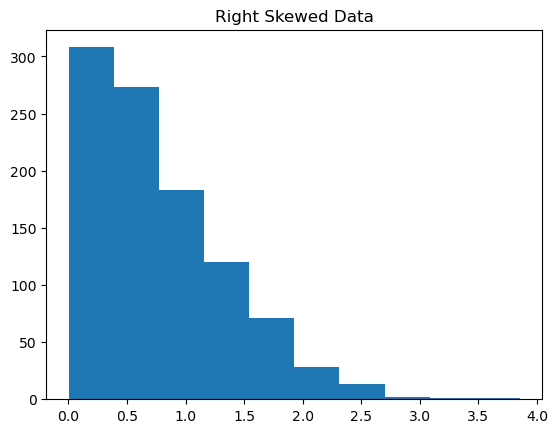

In [4]:
## Sqrt transformation
right_skew_sqrt = np.sqrt(right_skew)

plt.hist(right_skew_sqrt)
plt.title("Right Skewed Data")
plt.show()

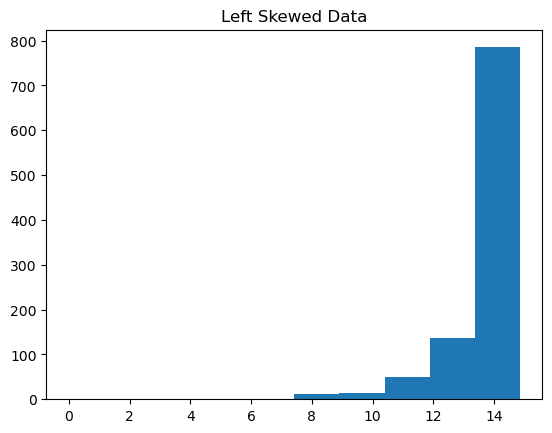

In [5]:
# Reflect the data around a constant (e.g., the maximum value) to make it left-skewed
left_skew = np.max(right_skew) - right_skew

plt.hist(left_skew)
plt.title("Left Skewed Data")
plt.show()

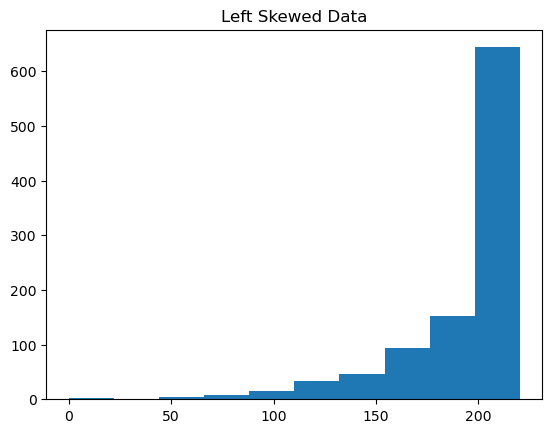

In [6]:
## Squared transformation
left_skew_sq = left_skew**2

plt.hist(left_skew_sq)
plt.title("Left Skewed Data")
plt.show()

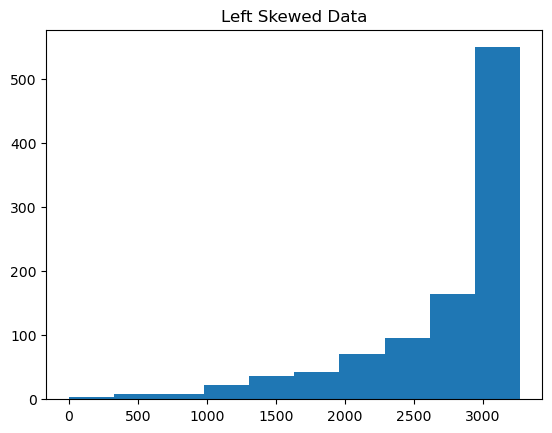

In [7]:
## Cube transformation
left_skew_cube = left_skew**3

plt.hist(left_skew_cube)
plt.title("Left Skewed Data")
plt.show()

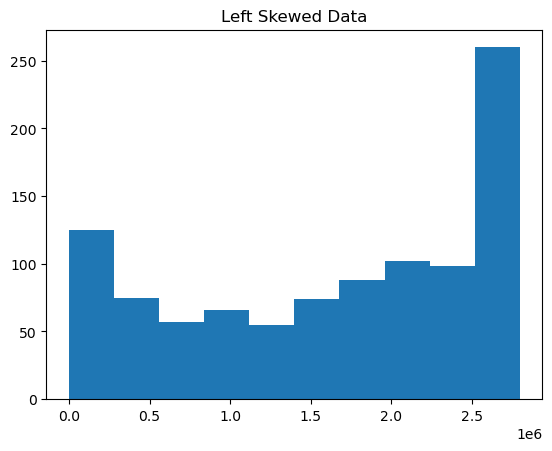

In [8]:
## Exponential transformation
left_skew_exp = np.exp(left_skew)

plt.hist(left_skew_exp)
plt.title("Left Skewed Data")
plt.show()

## Standardization and normalization

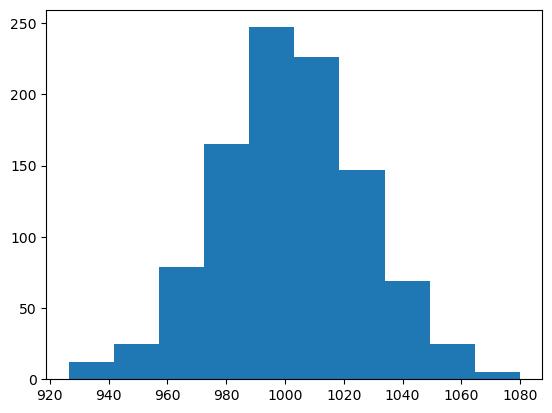

In [9]:
X = np.random.normal(loc = 1000, scale = 25, size = 1000).reshape(-1, 1)
plt.hist(X)
plt.show()

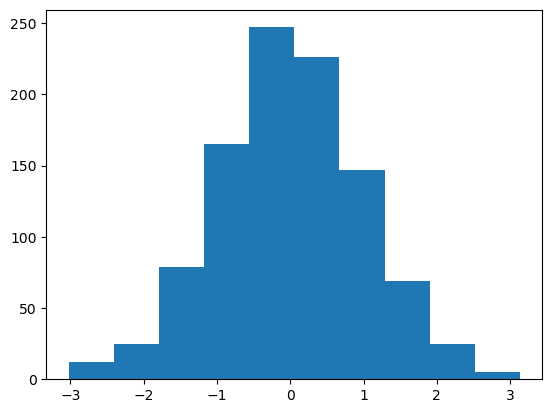

In [10]:
## Standardize (z-score)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

plt.hist(X_std)
plt.show()

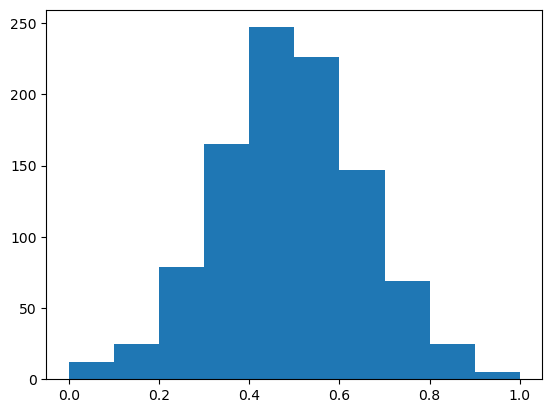

In [11]:
## Normalize (min-max)
from sklearn.preprocessing import MinMaxScaler

X_norm = MinMaxScaler().fit_transform(X) ## All in one...

plt.hist(X_norm)
plt.show()

## Imputation

In [12]:
df = pd.read_csv("./datafiles/employees_dataset_with_missing2.csv")
df.head()

,age,income,education_years,experience,credit_score
0,NaN,70990.331549,11.974465,0.460962,563.650640
1,33.617357,63869.505244,13.566444,5.698075,646.879651
2,41.476885,50894.455549,11.622740,7.931972,651.801687
3,50.230299,40295.948334,13.076115,NaN,697.263035
4,32.658466,60473.349704,8.319156,12.782766,513.314164


In [13]:
# Identify missing values
print('Check Null values \n',np.sum(np.isnan(df)))

Check Null values 
 age                116
income             149
education_years     91
experience         128
credit_score         0
dtype: int64


/opt/homebrew/Caskroom/miniforge/base/envs/geog5160/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [14]:
## Split into training and testing

all_vars = ['age', 'income', 'education_years', 'experience']
            
X = df[all_vars]
y = df['credit_score']

In [15]:
## Try fitting a simple model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
## regressor.fit(X, Y) ## Doesn't work due to NAs

In [16]:
X.head()

,age,income,education_years,experience
0,NaN,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,NaN
4,32.658466,60473.349704,8.319156,12.782766


### Simple imputation

In [17]:
print(f'Mean age       : {np.mean(df['age']):.3f}')
print(f'Mean experience: {np.mean(df['experience']):.3f}')

Mean age       : 35.280
Mean experience: 9.999


In [18]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)
X_imputed.head()

,age,income,education_years,experience
0,35.279903,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,9.999094
4,32.658466,60473.349704,8.319156,12.782766


In [19]:
regressor.fit(X_imputed, y) ## Now it works!

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
print('\nCoefficient :',regressor.coef_)
print('Intercept :',regressor.intercept_)


Coefficient : [-3.06576521e-01 -3.66087646e-04  1.30831224e+00  3.59588819e-01]
Intercept : 652.6349815405331


### KNN imputer

In [21]:
from sklearn.impute import KNNImputer

## Create KNNImputer object with 2 neighbors
knn_imputer = KNNImputer(n_neighbors=2)

## Fit and transform the data
X_knn_imputed = knn_imputer.fit_transform(X)
X_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_knn_imputed.head()

,age,income,education_years,experience
0,29.052459,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,16.909106
4,32.658466,60473.349704,8.319156,12.782766


### Iterative imputer

In [22]:
from sklearn.experimental import enable_iterative_imputer ## Note this is still currently in experimental
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor ## Algorithm for imputation

In [23]:
rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    random_state=42,
    max_iter=5 ## Number of updates
)

In [24]:
X_rf_imputed = pd.DataFrame(
    rf_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_rf_imputed.head()

/opt/homebrew/Caskroom/miniforge/base/envs/geog5160/lib/python3.12/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,age,income,education_years,experience
0,36.583605,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,13.333607
4,32.658466,60473.349704,8.319156,12.782766


The default algorithm (`BayesianRidge`) has advantage of allowing multiple imputation

In [25]:
from sklearn.linear_model import BayesianRidge

rf_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    random_state=42,
    max_iter=5,
    sample_posterior=True
)

X_rf_imputed = pd.DataFrame(
    rf_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_rf_imputed.head()

,age,income,education_years,experience
0,55.715286,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,7.693746
4,32.658466,60473.349704,8.319156,12.782766


In [26]:
rf_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    random_state=4321,
    max_iter=5,
    sample_posterior=True
)

X_rf_imputed = pd.DataFrame(
    rf_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_rf_imputed.head()

,age,income,education_years,experience
0,47.168497,70990.331549,11.974465,0.460962
1,33.617357,63869.505244,13.566444,5.698075
2,41.476885,50894.455549,11.622740,7.931972
3,50.230299,40295.948334,13.076115,9.803985
4,32.658466,60473.349704,8.319156,12.782766


## PCA transformation

In [27]:
df = pd.read_csv('datafiles/breast_cancer_data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [28]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [29]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:2])

[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]]


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
print(X_train_pca)

[[ 4.54908308e+00  9.41717321e+00]
 [ 8.98390371e+00  3.48443829e-01]
 [-2.18387278e+00  3.34216949e+00]
 [-2.53992691e+00  7.17342176e-01]
 [-2.25789278e+00  2.63255649e+00]
 [ 4.11060110e+00  2.83744068e+00]
 [ 3.25931564e+00  4.53528423e+00]
 [-3.24375729e+00 -3.77193585e-01]
 [-2.39570069e+00  3.23831742e-02]
 [ 3.33787340e+00 -2.40868713e+00]
 [-8.97085142e-01  9.71480118e-01]
 [ 4.27020833e+00 -4.08835623e+00]
 [ 3.14448278e+00  1.38409522e+00]
 [-2.61236008e+00  1.47737138e+00]
 [-3.15626177e+00 -1.42692982e+00]
 [ 4.94935215e+00 -1.24963477e+00]
 [ 9.25865794e+00  1.62305924e+00]
 [ 5.93445485e+00  3.42829497e+00]
 [-2.82906040e+00 -2.41935929e+00]
 [-3.31053210e+00 -5.24444943e-02]
 [-2.10256540e+00 -2.41916679e+00]
 [ 4.81497073e+00  3.14530988e+00]
 [-4.86026086e-01  1.11761752e-01]
 [-2.17014740e+00  2.04250503e+00]
 [ 1.30782725e+00  9.62061575e-01]
 [ 1.25525108e+00  2.53907129e-01]
 [-2.89655918e+00  3.63107445e-01]
 [ 4.89976908e+00 -4.19595024e+00]
 [-3.60573236e+00  7

In [34]:
print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance: [0.4325482  0.19732988]
Cumulative: [0.4325482  0.62987809]


In [35]:
X_test_pca = pca.transform(X_test)

In [36]:
logreg = LogisticRegression()
logreg.fit(X_train_pca, y_train)

y_pred = logreg.predict(X_test_pca)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [37]:
print('\nCoefficient :',logreg.coef_)
print('Intercept :',logreg.intercept_)


Coefficient : [[ 1.89080372 -1.08847514]]
Intercept : [-0.45574444]


## Imbalanced data

In [38]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

def get_accuracy(y, y_pred):
    acc = accuracy_score(y_test, y_test_pred)
    bacc = balanced_accuracy_score(y_test, y_test_pred)
    print(f'Accuracy: {acc:.4f}')
    print(f'Balanced accuracy: {bacc:.4f}')

def imbalance_ratio(y):
    print("Class Distribution:")
    print(y.value_counts())

    # Imbalance ratio (%)
    imbalance_ratio = y.value_counts().min() / y.value_counts().max()
    print(f"Imbalance ratio: {imbalance_ratio:.3f}")

In [39]:
df = pd.read_csv("./datafiles/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [40]:
# Drop columns 'day' and 'month' 
df = df.drop(columns=['day', 'month'])

In [41]:
from sklearn.preprocessing import StandardScaler

# Loop One-Hot Encoding for categorical columns 
all_vars = ['job', 'marital', 'education', 'default', 'housing', 
                       'loan', 'contact', 'duration', 'campaign', 
                       'pdays', 'previous', 'poutcome']

X = df[all_vars]
y = df['y']

In [42]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()

,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown
0,261,1,-1,0,0,0,0,1,0,0,...,1,0,0,1,0,0,1,0,0,1
1,151,1,-1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
2,76,1,-1,0,0,1,0,0,0,0,...,0,0,0,1,1,0,1,0,0,1
3,92,1,-1,0,1,0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,1
4,198,1,-1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,1


In [43]:
imbalance_ratio(y)

Class Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64
Imbalance ratio: 0.132


### Naive model

In [44]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
## Simple random forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_test_pred = rf.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.8844
Balanced accuracy: 0.6749


In [46]:
## Random forest with inverse frequency weights

rf_balanced = RandomForestClassifier(class_weight='balanced', random_state=42, max_depth=2)
rf_balanced.fit(X_train, y_train)

y_test_pred = rf_balanced.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.7592
Balanced accuracy: 0.7531


In [47]:
## Random forest with custom weights
custom_weights = {'no': 1.0, 'yes': 10.0}
rf_balanced = RandomForestClassifier(class_weight=custom_weights, random_state=42, max_depth=2)
rf_balanced.fit(X_train, y_train)

y_test_pred = rf_balanced.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.6075
Balanced accuracy: 0.7377


In [48]:
## Random forest with balanced subsampling
from imblearn.ensemble import BalancedRandomForestClassifier

brf = BalancedRandomForestClassifier(random_state=42)
brf.fit(X_train, y_train)

y_test_pred = brf.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.8263
Balanced accuracy: 0.8051


### Resampling

#### Random oversampling

In [49]:
from imblearn.over_sampling import RandomOverSampler

# Perform random oversampling
ros = RandomOverSampler(random_state=0)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

imbalance_ratio(y_train_ros)

Class Distribution:
y
no     31970
yes    31970
Name: count, dtype: int64
Imbalance ratio: 1.000


In [50]:
rf_ros = RandomForestClassifier(random_state=42)

rf_ros.fit(X_train_ros, y_train_ros)

y_test_pred = rf_ros.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.8713
Balanced accuracy: 0.7022


#### Random undersampling

In [51]:
from imblearn.under_sampling import RandomUnderSampler

# Perform random sampling
rus = RandomUnderSampler(random_state=0)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

imbalance_ratio(y_train_rus)

Class Distribution:
y
no     4198
yes    4198
Name: count, dtype: int64
Imbalance ratio: 1.000


In [52]:
rf_rus = RandomForestClassifier(random_state=42)

rf_rus.fit(X_train_rus, y_train_rus)

y_test_pred = rf_rus.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.7875
Balanced accuracy: 0.8001


#### SMOTE

In [53]:
from imblearn.over_sampling import SMOTE

# Perform SMOTE
ros = SMOTE(random_state=0)
X_train_smote, y_train_smote = ros.fit_resample(X_train, y_train)

imbalance_ratio(y_train_smote)

Class Distribution:
y
no     31970
yes    31970
Name: count, dtype: int64
Imbalance ratio: 1.000


In [54]:
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote, y_train_smote)

y_test_pred = rf_smote.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.8640
Balanced accuracy: 0.7028


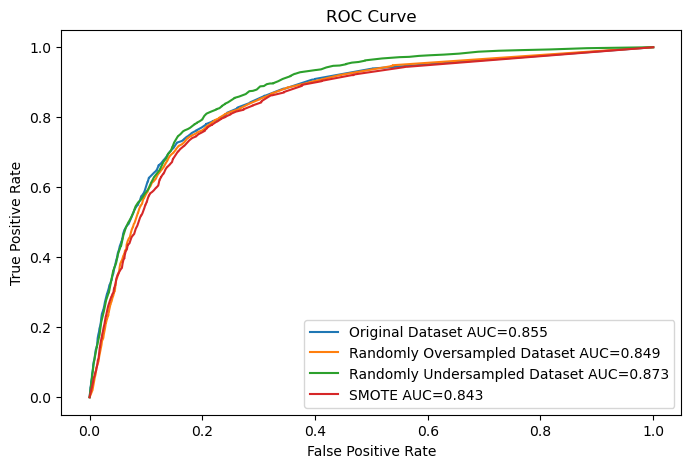

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

# Helper function for plotting ROC
def plot_roc(ax, est, X_train, y_train, X_test, y_test, title):
    y_test_pred = est.predict_proba(X_test)[:,1]
    fpr, tpr, thresh = roc_curve(y_test, y_test_pred, pos_label='yes')
    auc = roc_auc_score(y_test, y_test_pred)
    ax.plot(fpr,tpr,label=f"{title} AUC={auc:.3f}")

    ax.set_title('ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc=0)


fig,ax = plt.subplots(1,1,figsize=(8,5))
plot_roc(ax, rf, X_train, y_train, X_test, y_test, 'Original Dataset')
plot_roc(ax, rf_ros, X_train_ros, y_train_ros, X_test, y_test, 'Randomly Oversampled Dataset')
plot_roc(ax, rf_rus, X_train_rus, y_train_rus, X_test, y_test, 'Randomly Undersampled Dataset')
plot_roc(ax, rf_smote, X_train_smote, y_train_smote, X_test, y_test, 'SMOTE')

In [56]:
y_test_pred = rf.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred[:,1], pos_label='yes')

threshold_rf = thresholds[np.argmax(tpr - fpr)]
print(f"Threshold for yes/no: {threshold_rf:.3f}")

Threshold for yes/no: 0.096


## Pipelines

In [57]:
df = pd.read_csv('datafiles/breast_cancer_data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [58]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [59]:
# perform scaling
mms = MinMaxScaler()
X_train = mms.fit_transform(X_train)
X_test = mms.transform(X_test)

# perform pca
pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# train model
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

# generate predictions
y_test_pred = rfc.predict(X_test)

In [60]:
get_accuracy(y_test, y_test_pred)

Accuracy: 0.9580
Balanced accuracy: 0.9554


### Pipeline

In [61]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [62]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[('scaler', MinMaxScaler()),
                   ('pca', PCA(n_components=2)),
                   ('model', RandomForestClassifier(random_state=42))])

In [63]:
from sklearn import set_config

set_config(display="diagram")
pipeline  # click on the diagram below to see the details of each step

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


In [64]:
pipeline.fit(X_train, y_train)
y_test_pred = pipeline.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.9580
Balanced accuracy: 0.9554


### Pipeline tuning

In [65]:
pipeline.steps

[('scaler', MinMaxScaler()),
 ('pca', PCA(n_components=2)),
 ('model', RandomForestClassifier(random_state=42))]

Parameters of the estimators in the pipeline are accessible using the <estimator>__<parameter> syntax

In [66]:
pipeline.set_params(pca__n_components=10)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'


In [67]:
pipeline = Pipeline(steps=[('scaler', MinMaxScaler()),
                   ('pca', PCA(n_components=2)),
                   ('model', RandomForestClassifier(random_state=42))])

param_grid = {
    'pca__n_components':[2, 5],
    'model__n_estimators': [100, 1000]
}

In [68]:
from sklearn.model_selection import GridSearchCV

gs = GridSearchCV(pipeline,
                  param_grid=param_grid,
                  cv=3,
                  scoring='f1_micro',
                  n_jobs=-1)
gs.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__n_estimators': [100, 1000], 'pca__n_components': [2, 5]}"
,scoring,'f1_micro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


In [69]:
model = gs.best_estimator_
y_test_pred = model.predict(X_test)

get_accuracy(y_test, y_test_pred)

Accuracy: 0.9580
Balanced accuracy: 0.9554
